In [42]:
import pandas as pd

df = pd.read_csv("zepto_utf8.csv")

print(df.shape)

print(df.columns)

df.head(15)      


(3732, 9)
Index(['Category', 'name', 'mrp', 'discountPercent', 'availableQuantity',
       'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity'],
      dtype='object')


,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250
5,Fruits & Vegetables,Potato,3500,17,3,2900,1000,False,1
6,Fruits & Vegetables,Lemon,7500,16,3,6300,200,False,200
7,Fruits & Vegetables,Watermelon,5800,15,3,4900,58,False,1
8,Fruits & Vegetables,Capsicum Green,2300,17,3,1900,250,False,250
9,Fruits & Vegetables,Chilli Green,1900,15,3,1600,100,False,100


In [43]:
df.describe()

,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,quantity
count,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000,3732.000000
mean,15680.117899,7.617095,4.008574,14192.834941,387.843783,213.270900
std,16088.807618,9.211733,2.203511,13850.726265,678.096509,194.730976
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6000.000000,0.000000,2.000000,5500.000000,100.000000,50.000000
50%,11000.000000,6.000000,5.000000,10400.000000,225.000000,186.000000
75%,20000.000000,10.000000,6.000000,18400.000000,450.000000,340.000000
max,260000.000000,51.000000,6.000000,139900.000000,10000.000000,1500.000000


In [44]:
df.isnull().sum()

Category                  0
name                      0
mrp                       0
discountPercent           0
availableQuantity         0
discountedSellingPrice    0
weightInGms               0
outOfStock                0
quantity                  0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(2)

In [46]:
df.columns = [
    "category",
    "product_name",
    "mrp",
    "discount_percent",
    "available_quantity",
    "discounted_price",
    "weight_gms",
    "out_of_stock",
    "quantity"
]

In [47]:
duplicates = df[df.duplicated(keep=False)]
duplicates

,category,product_name,mrp,discount_percent,available_quantity,discounted_price,weight_gms,out_of_stock,quantity
2908,Personal Care,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
2946,Personal Care,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
3252,Paan Corner,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250
3290,Paan Corner,Listerine Cool Mint Mouthwash - Mild Taste,15000,10,6,13500,250,False,250


In [48]:
df = df.drop_duplicates().reset_index(drop=True)

In [49]:
df.duplicated().sum()

np.int64(0)

In [72]:
df["mrp"] = df["mrp"] / 100

In [73]:
df["discounted_price"] = df["discounted_price"] / 100

In [74]:
df["inventory_value"] = (df["available_quantity"] * df["discounted_price"])

In [75]:
df[[
    "product_name",
    "available_quantity",
    "discounted_price",
    "inventory_value"
]].head()

,product_name,available_quantity,discounted_price,inventory_value
0,Onion,3,21.0,63.0
1,Tomato Hybrid,3,35.0,105.0
2,Tender Coconut,3,43.0,129.0
3,Coriander Leaves,3,17.0,51.0
4,Ladies Finger,3,12.0,36.0


In [76]:
df["discount_amount"] = df["mrp"] - df["discounted_price"]

In [77]:
df[[
    "product_name",
    "mrp",
    "discounted_price",
    "discount_amount"
]].head()

,product_name,mrp,discounted_price,discount_amount
0,Onion,25.0,21.0,4.0
1,Tomato Hybrid,42.0,35.0,7.0
2,Tender Coconut,51.0,43.0,8.0
3,Coriander Leaves,20.0,17.0,3.0
4,Ladies Finger,14.0,12.0,2.0


In [78]:
def stock_status(qty):
    if qty == 0:
        return "Out of Stock"
    elif qty <= 2:
        return "Critical"
    elif qty <= 4:
        return "Low"
    else:
        return "Healthy"

df["stock_status"] = df["available_quantity"].apply(stock_status)

In [79]:
df["stock_status"].value_counts()

stock_status
Healthy         1966
Low              765
Critical         546
Out of Stock     453
Name: count, dtype: int64

In [80]:
total_inventory_value = df["inventory_value"].sum()

In [81]:
inventory_by_category = (
    df.groupby("category")["inventory_value"]
      .sum()
      .sort_values(ascending=False)
)

inventory_by_category

category
Cooking Essentials       337369.0
Munchies                 337369.0
Paan Corner              270039.0
Personal Care            270039.0
Chocolates & Candies     224385.0
Ice Cream & Desserts     224385.0
Packaged Food            224385.0
Home & Cleaning          122661.0
Health & Hygiene          64180.0
Beverages                 55051.0
Dairy, Bread & Batter     55051.0
Biscuits                  25007.6
Meats, Fish & Eggs        20693.0
Fruits & Vegetables       10846.0
Name: inventory_value, dtype: float64

In [82]:
df["category"].value_counts()

category
Cooking Essentials       514
Munchies                 514
Packaged Food            388
Ice Cream & Desserts     388
Chocolates & Candies     388
Personal Care            343
Paan Corner              343
Home & Cleaning          194
Biscuits                 147
Dairy, Bread & Batter    129
Beverages                129
Health & Hygiene          97
Fruits & Vegetables       93
Meats, Fish & Eggs        63
Name: count, dtype: int64

In [83]:
df["stock_status"].value_counts()

stock_status
Healthy         1966
Low              765
Critical         546
Out of Stock     453
Name: count, dtype: int64

In [84]:
df["out_of_stock"].value_counts()

out_of_stock
False    3277
True      453
Name: count, dtype: int64

In [85]:
df.nlargest(10, "inventory_value")[
    ["product_name", "category", "inventory_value"]
]

,product_name,category,inventory_value
517,Borges Extra Light Olive Oil Bottle,Cooking Essentials,8394.0
1031,Borges Extra Light Olive Oil Bottle,Munchies,8394.0
363,Praakritik Natural Desi Gir Cow A2 Ghee,Cooking Essentials,7830.0
877,Praakritik Natural Desi Gir Cow A2 Ghee,Munchies,7830.0
144,Saffola Gold (Jar),Cooking Essentials,7440.0
658,Saffola Gold (Jar),Munchies,7440.0
121,Dhara Kachi Ghani Mustard Oil Jar,Cooking Essentials,6858.0
635,Dhara Kachi Ghani Mustard Oil Jar,Munchies,6858.0
146,Fortune Rice Bran Health Oil (Jar),Cooking Essentials,6234.0
660,Fortune Rice Bran Health Oil (Jar),Munchies,6234.0


In [86]:
df.nlargest(10, "discount_percent")[
    ["product_name", "discount_percent"]
]

,product_name,discount_percent
2608,Dukes Waffy Chocolate Wafers,51
2615,Dukes Waffy Orange Wafers,51
2619,Dukes Waffy Strawberry Wafers,51
198,Chef's Basket Durum Wheat Elbow Pasta,50
217,Chef's Basket Durum Wheat Fusilli Pasta,50
278,Ceres Foods Fish Mustard Instant Liquid Masala,50
395,Ceres Foods Laal Maas Instant Liquid Masala,50
490,Ceres Foods Nalli Nihari Instant Liquid Masala,50
593,Chef's Basket Durum Wheat Penne Pasta,50
712,Chef's Basket Durum Wheat Elbow Pasta,50


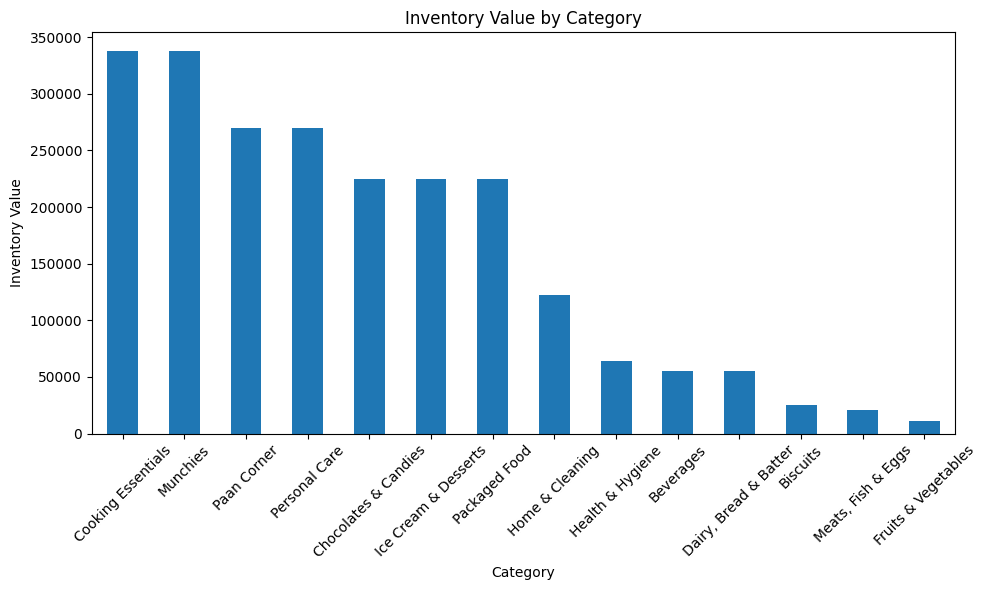

In [87]:
import matplotlib.pyplot as plt

inventory_by_category = (
    df.groupby("category")["inventory_value"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

inventory_by_category.plot(kind="bar")

plt.title("Inventory Value by Category")
plt.xlabel("Category")
plt.ylabel("Inventory Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

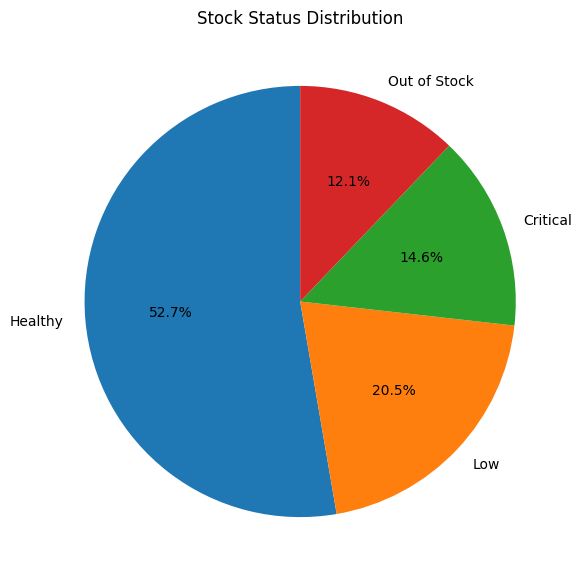

In [88]:
plt.figure(figsize=(7,7))

df["stock_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Stock Status Distribution")
plt.ylabel("")

plt.show()

In [89]:
top10 = df.nlargest(10, "inventory_value")
top10

,category,product_name,mrp,discount_percent,available_quantity,discounted_price,weight_gms,out_of_stock,quantity,inventory_value,discount_amount,stock_status
517,Cooking Essentials,Borges Extra Light Olive Oil Bottle,2600.0,46,6,1399.0,2000,False,2,8394.0,1201.0,Healthy
1031,Munchies,Borges Extra Light Olive Oil Bottle,2600.0,46,6,1399.0,2000,False,2,8394.0,1201.0,Healthy
363,Cooking Essentials,Praakritik Natural Desi Gir Cow A2 Ghee,1450.0,10,6,1305.0,540,False,540,7830.0,145.0,Healthy
877,Munchies,Praakritik Natural Desi Gir Cow A2 Ghee,1450.0,10,6,1305.0,540,False,540,7830.0,145.0,Healthy
144,Cooking Essentials,Saffola Gold (Jar),1240.0,0,6,1240.0,5000,False,5,7440.0,0.0,Healthy
658,Munchies,Saffola Gold (Jar),1240.0,0,6,1240.0,5000,False,5,7440.0,0.0,Healthy
121,Cooking Essentials,Dhara Kachi Ghani Mustard Oil Jar,1250.0,8,6,1143.0,5000,False,5,6858.0,107.0,Healthy
635,Munchies,Dhara Kachi Ghani Mustard Oil Jar,1250.0,8,6,1143.0,5000,False,5,6858.0,107.0,Healthy
146,Cooking Essentials,Fortune Rice Bran Health Oil (Jar),1050.0,1,6,1039.0,5000,False,5,6234.0,11.0,Healthy
660,Munchies,Fortune Rice Bran Health Oil (Jar),1050.0,1,6,1039.0,5000,False,5,6234.0,11.0,Healthy


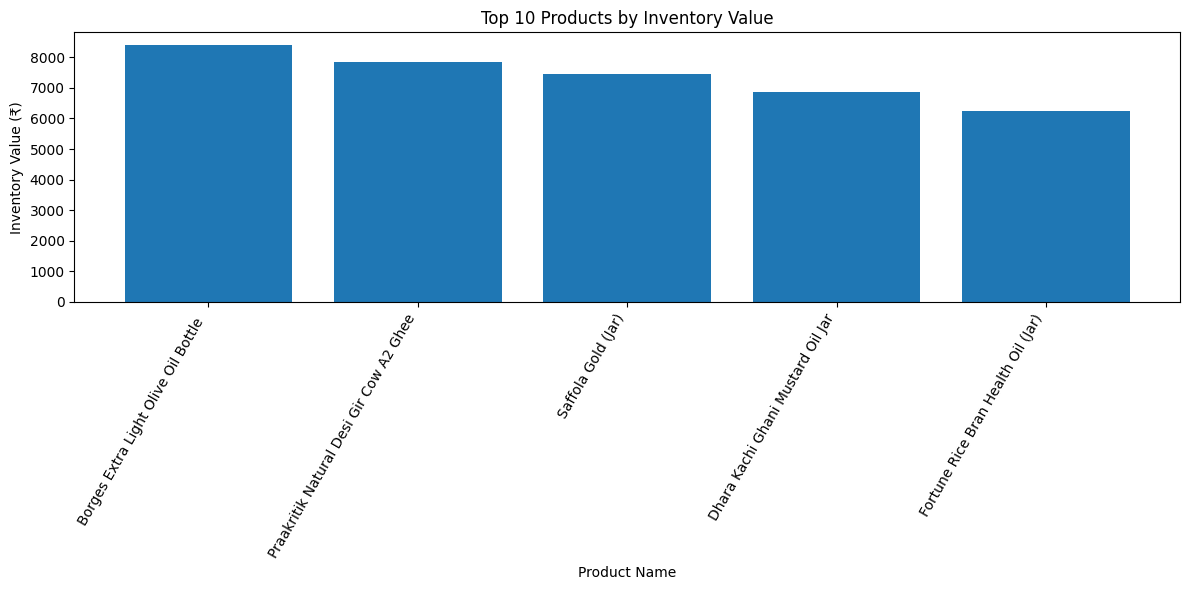

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top10["product_name"],
    top10["inventory_value"]
)

plt.title("Top 10 Products by Inventory Value")
plt.xlabel("Product Name")
plt.ylabel("Inventory Value (₹)")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.show()

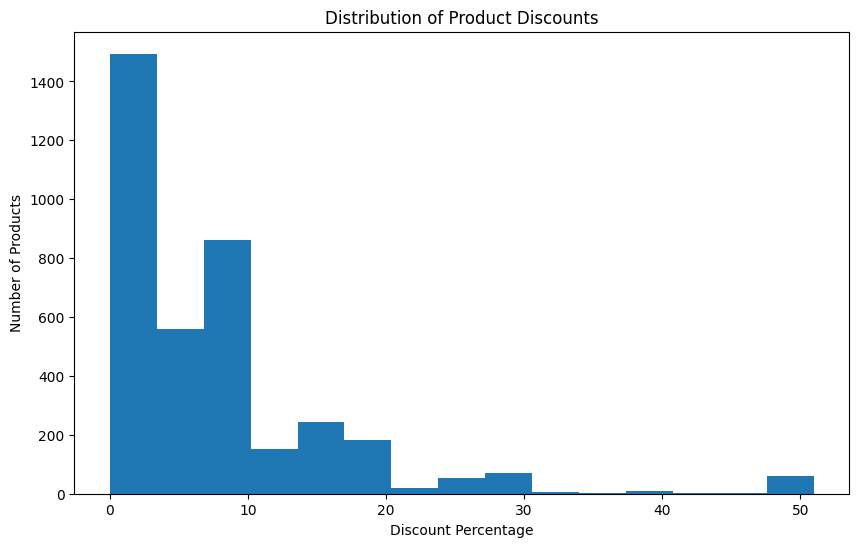

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df["discount_percent"], bins=15)

plt.title("Distribution of Product Discounts")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")

plt.show()

In [92]:
top10_expensive = df.nlargest(10, "discounted_price")

top10_expensive[["product_name", "discounted_price"]]

,product_name,discounted_price
517,Borges Extra Light Olive Oil Bottle,1399.0
1031,Borges Extra Light Olive Oil Bottle,1399.0
363,Praakritik Natural Desi Gir Cow A2 Ghee,1305.0
877,Praakritik Natural Desi Gir Cow A2 Ghee,1305.0
144,Saffola Gold (Jar),1240.0
658,Saffola Gold (Jar),1240.0
121,Dhara Kachi Ghani Mustard Oil Jar,1143.0
635,Dhara Kachi Ghani Mustard Oil Jar,1143.0
511,Dhara Filtered Groundnut Oil (Jar),1050.0
1025,Dhara Filtered Groundnut Oil (Jar),1050.0


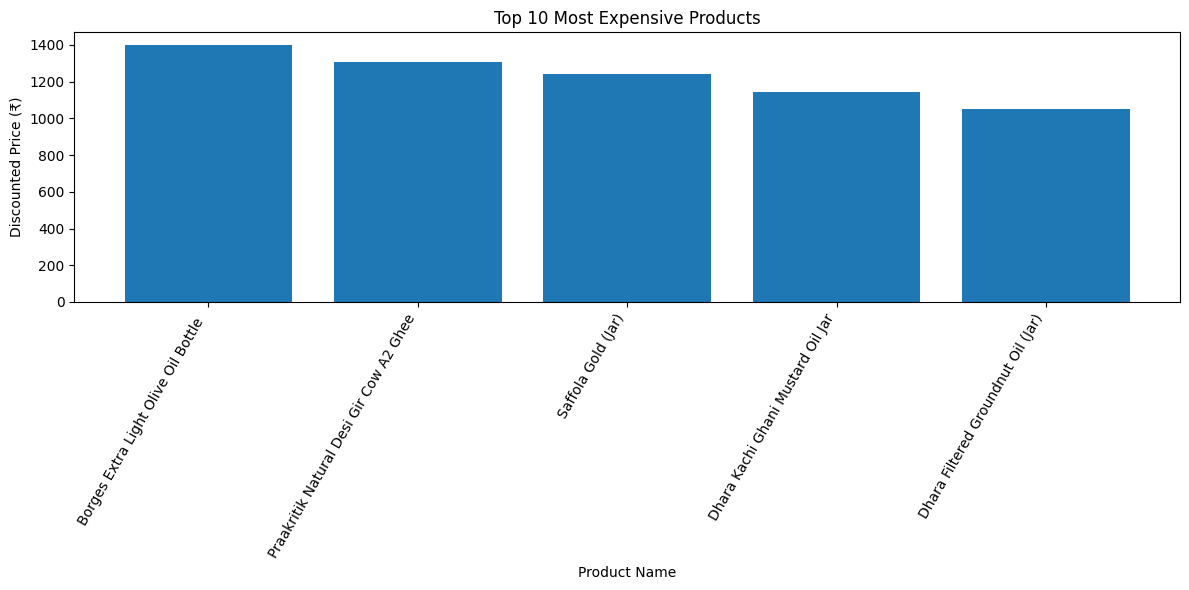

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top10_expensive["product_name"],
    top10_expensive["discounted_price"]
)

plt.title("Top 10 Most Expensive Products")
plt.xlabel("Product Name")
plt.ylabel("Discounted Price (₹)")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.show()

In [94]:
avg_discount = (
    df.groupby("category")["discount_percent"]
      .mean()
      .sort_values(ascending=False)
)

avg_discount

category
Fruits & Vegetables      15.462366
Meats, Fish & Eggs       11.031746
Chocolates & Candies      8.324742
Ice Cream & Desserts      8.324742
Packaged Food             8.324742
Biscuits                  8.244898
Health & Hygiene          8.051546
Cooking Essentials        7.163424
Munchies                  7.163424
Beverages                 7.155039
Dairy, Bread & Batter     7.155039
Paan Corner               6.239067
Personal Care             6.239067
Home & Cleaning           5.675258
Name: discount_percent, dtype: float64

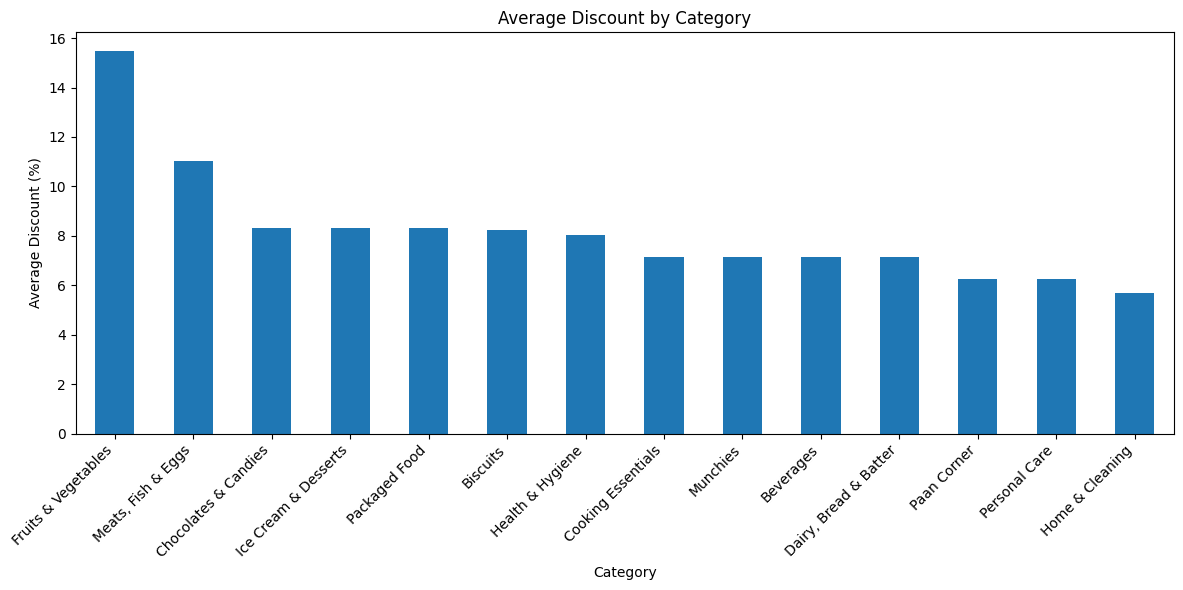

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

avg_discount.plot(kind="bar")

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [96]:
out_of_stock_category = (
    df[df["out_of_stock"] == True]
      .groupby("category")
      .size()
      .sort_values(ascending=False)
)

out_of_stock_category

category
Cooking Essentials       64
Munchies                 64
Chocolates & Candies     45
Ice Cream & Desserts     45
Packaged Food            45
Biscuits                 42
Beverages                28
Dairy, Bread & Batter    28
Paan Corner              21
Personal Care            21
Home & Cleaning          19
Health & Hygiene         13
Meats, Fish & Eggs       12
Fruits & Vegetables       6
dtype: int64

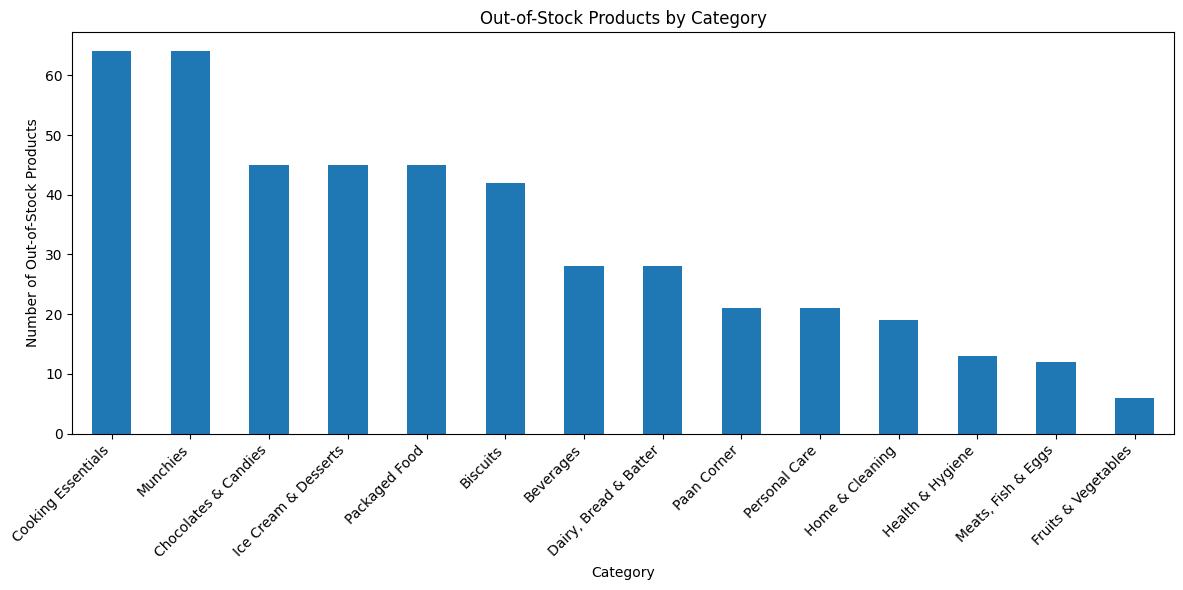

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

out_of_stock_category.plot(kind="bar")

plt.title("Out-of-Stock Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Out-of-Stock Products")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [98]:
df.to_csv("cleaned_zepto_dataset.csv", index=False)

In [99]:
import os

os.path.exists("cleaned_zepto_dataset.csv")

True

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

In [2]:
df = pd.read_csv("cleaned_zepto_dataset.csv")

df.head()

,category,product_name,mrp,discount_percent,available_quantity,discounted_price,weight_gms,out_of_stock,quantity,inventory_value,discount_amount,stock_status
0,Fruits & Vegetables,Onion,25.0,16,3,21.0,1000,False,1,63.0,4.0,Low
1,Fruits & Vegetables,Tomato Hybrid,42.0,16,3,35.0,1000,False,1,105.0,7.0,Low
2,Fruits & Vegetables,Tender Coconut,51.0,15,3,43.0,58,False,1,129.0,8.0,Low
3,Fruits & Vegetables,Coriander Leaves,20.0,15,3,17.0,100,False,100,51.0,3.0,Low
4,Fruits & Vegetables,Ladies Finger,14.0,14,3,12.0,250,False,250,36.0,2.0,Low


In [3]:
df.shape

(3730, 12)

In [4]:
dates = pd.date_range(
    start="2025-01-01",
    end="2025-12-31",
    freq="D"
)

print("Total Days:", len(dates))

dates[:5]

Total Days: 365


DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05'],
              dtype='datetime64[ns]', freq='D')

In [5]:
products = df.copy()
products.head()

,category,product_name,mrp,discount_percent,available_quantity,discounted_price,weight_gms,out_of_stock,quantity,inventory_value,discount_amount,stock_status
0,Fruits & Vegetables,Onion,25.0,16,3,21.0,1000,False,1,63.0,4.0,Low
1,Fruits & Vegetables,Tomato Hybrid,42.0,16,3,35.0,1000,False,1,105.0,7.0,Low
2,Fruits & Vegetables,Tender Coconut,51.0,15,3,43.0,58,False,1,129.0,8.0,Low
3,Fruits & Vegetables,Coriander Leaves,20.0,15,3,17.0,100,False,100,51.0,3.0,Low
4,Fruits & Vegetables,Ladies Finger,14.0,14,3,12.0,250,False,250,36.0,2.0,Low


In [6]:
dates_df = pd.DataFrame({"date": dates})

In [7]:
dates_df.head()

,date
0,2025-01-01
1,2025-01-02
2,2025-01-03
3,2025-01-04
4,2025-01-05


In [8]:
products["key"] = 1
dates_df["key"] = 1

In [9]:
sales_df = pd.merge(products, dates_df, on="key")


In [10]:
sales_df.drop("key", axis=1, inplace=True)

In [12]:
sales_df.head()

,category,product_name,mrp,discount_percent,available_quantity,discounted_price,weight_gms,out_of_stock,quantity,inventory_value,discount_amount,stock_status,date
0,Fruits & Vegetables,Onion,25.0,16,3,21.0,1000,False,1,63.0,4.0,Low,2025-01-01
1,Fruits & Vegetables,Onion,25.0,16,3,21.0,1000,False,1,63.0,4.0,Low,2025-01-02
2,Fruits & Vegetables,Onion,25.0,16,3,21.0,1000,False,1,63.0,4.0,Low,2025-01-03
3,Fruits & Vegetables,Onion,25.0,16,3,21.0,1000,False,1,63.0,4.0,Low,2025-01-04
4,Fruits & Vegetables,Onion,25.0,16,3,21.0,1000,False,1,63.0,4.0,Low,2025-01-05


In [13]:
df["category"].unique()

array(['Fruits & Vegetables', 'Cooking Essentials', 'Munchies',
       'Dairy, Bread & Batter', 'Beverages', 'Packaged Food',
       'Ice Cream & Desserts', 'Chocolates & Candies',
       'Meats, Fish & Eggs', 'Biscuits', 'Personal Care', 'Paan Corner',
       'Home & Cleaning', 'Health & Hygiene'], dtype=object)

In [14]:
sales_df["base_demand"] = (
    5
    + sales_df["available_quantity"] * 0.08
    + sales_df["discount_percent"] * 0.30
).round().astype(int)


In [16]:
sales_df[
    [
        "product_name",
        "available_quantity",
        "discount_percent",
        "base_demand"
    ]
].head(15)

,product_name,available_quantity,discount_percent,base_demand
0,Onion,3,16,10
1,Onion,3,16,10
2,Onion,3,16,10
3,Onion,3,16,10
4,Onion,3,16,10
5,Onion,3,16,10
6,Onion,3,16,10
7,Onion,3,16,10
8,Onion,3,16,10
9,Onion,3,16,10


In [17]:
sales_df["random_factor"] = np.random.uniform(
    0.8,
    1.2,
    size=len(sales_df)
)

In [18]:
sales_df[
    [
        "product_name",
        "base_demand",
        "random_factor"
    ]
].head()

,product_name,base_demand,random_factor
0,Onion,10,0.963505
1,Onion,10,1.121952
2,Onion,10,1.162915
3,Onion,10,1.149752
4,Onion,10,0.823209


In [35]:
sales_df["day"] = sales_df["date"].dt.day_name()

In [36]:
sales_df[["date", "day"]].head()

,date,day
0,2025-01-01,Wednesday
1,2025-01-02,Thursday
2,2025-01-03,Friday
3,2025-01-04,Saturday
4,2025-01-05,Sunday


In [37]:
sales_df["weekend_factor"] = np.where(
    sales_df["day"].isin(["Saturday", "Sunday"]),
    1.15,
    1.00
)

In [38]:

sales_df[["day", "weekend_factor"]].head(10)

,day,weekend_factor
0,Wednesday,1.00
1,Thursday,1.00
2,Friday,1.00
3,Saturday,1.15
4,Sunday,1.15
5,Monday,1.00
6,Tuesday,1.00
7,Wednesday,1.00
8,Thursday,1.00
9,Friday,1.00


In [39]:
sales_df["month"] = sales_df["date"].dt.month

sales_df[["date","month"]].head()

,date,month
0,2025-01-01,1
1,2025-01-02,1
2,2025-01-03,1
3,2025-01-04,1
4,2025-01-05,1


In [41]:
sales_df["season_factor"] = 1.0

In [42]:
summer_categories = [
    "Beverages",
    "Ice Cream & Desserts"
]

sales_df.loc[
    (sales_df["month"].isin([4, 5, 6])) &
    (sales_df["category"].isin(summer_categories)),
    "season_factor"
] = 1.15

In [43]:
festive_categories = [
    "Chocolates & Candies",
    "Home & Cleaning",
    "Cooking Essentials"
]

sales_df.loc[
    (sales_df["month"].isin([10, 11])) &
    (sales_df["category"].isin(festive_categories)),
    "season_factor"
] = 1.20

In [44]:
december_categories = [
    "Beverages",
    "Chocolates & Candies",
    "Cooking Essentials"
]

sales_df.loc[
    (sales_df["month"] == 12) &
    (sales_df["category"].isin(december_categories)),
    "season_factor"
] = 1.10

In [46]:
sales_df["price_factor"] = np.where(
    sales_df["discounted_price"] <= 100,
    1.20,
    np.where(
        sales_df["discounted_price"] <= 500,
        1.00,
        0.80
    )
)

In [47]:
sales_df["units_sold"] = (
    sales_df["base_demand"]
    * sales_df["random_factor"]
    * sales_df["weekend_factor"]
    * sales_df["season_factor"]
    * sales_df["price_factor"]
).round().astype(int)

In [48]:
sales_df["daily_revenue"] = (
    sales_df["units_sold"] * sales_df["discounted_price"]
).round(2)

sales_df[
    [
        "product_name",
        "discounted_price",
        "units_sold",
        "daily_revenue"
    ]
].head()

,product_name,discounted_price,units_sold,daily_revenue
0,Onion,21.0,12,252.0
1,Onion,21.0,13,273.0
2,Onion,21.0,14,294.0
3,Onion,21.0,16,336.0
4,Onion,21.0,11,231.0


In [49]:
sales_df["potential_revenue"] = (
    sales_df["units_sold"] * sales_df["mrp"]
).round(2)

In [50]:
sales_df["discount_loss"] = (
    sales_df["potential_revenue"]
    - sales_df["daily_revenue"]
).round(2)

In [51]:
sales_df[
    [
        "product_name",
        "units_sold",
        "daily_revenue",
        "potential_revenue",
        "discount_loss"
    ]
].head()

,product_name,units_sold,daily_revenue,potential_revenue,discount_loss
0,Onion,12,252.0,300.0,48.0
1,Onion,13,273.0,325.0,52.0
2,Onion,14,294.0,350.0,56.0
3,Onion,16,336.0,400.0,64.0
4,Onion,11,231.0,275.0,44.0


In [52]:
sales_df.shape

(1361450, 25)

In [53]:
sales_df.isnull().sum()

category              0
product_name          0
mrp                   0
discount_percent      0
available_quantity    0
discounted_price      0
weight_gms            0
out_of_stock          0
quantity              0
inventory_value       0
discount_amount       0
stock_status          0
date                  0
base_demand           0
random_factor         0
day                   0
year                  0
weekend_factor        0
month                 0
season_factor         0
units_sold            0
price_factor          0
daily_revenue         0
potential_revenue     0
discount_loss         0
dtype: int64

In [54]:
sales_df[
    [
        "units_sold",
        "daily_revenue",
        "discount_loss"
    ]
].describe()

,units_sold,daily_revenue,discount_loss
count,1.361450e+06,1.361450e+06,1.361450e+06
mean,8.634077e+00,1.150394e+03,1.837887e+02
std,3.592442e+00,1.189707e+03,6.630257e+02
min,3.000000e+00,0.000000e+00,0.000000e+00
25%,6.000000e+00,4.680000e+02,0.000000e+00
50%,8.000000e+00,8.320000e+02,4.800000e+01
75%,1.000000e+01,1.456000e+03,1.500000e+02
max,4.000000e+01,3.497500e+04,3.002500e+04


In [55]:
sales_df.sort_values(
    "discount_loss",
    ascending=False
)[
    [
        "product_name",
        "category",
        "mrp",
        "discounted_price",
        "units_sold",
        "discount_loss"
    ]
].head(10)

,product_name,category,mrp,discounted_price,units_sold,discount_loss
189017,Borges Extra Light Olive Oil Bottle,Cooking Essentials,2600.0,1399.0,25,30025.0
188988,Borges Extra Light Olive Oil Bottle,Cooking Essentials,2600.0,1399.0,25,30025.0
188996,Borges Extra Light Olive Oil Bottle,Cooking Essentials,2600.0,1399.0,25,30025.0
189031,Borges Extra Light Olive Oil Bottle,Cooking Essentials,2600.0,1399.0,24,28824.0
189024,Borges Extra Light Olive Oil Bottle,Cooking Essentials,2600.0,1399.0,23,27623.0
189038,Borges Extra Light Olive Oil Bottle,Cooking Essentials,2600.0,1399.0,23,27623.0
188987,Borges Extra Light Olive Oil Bottle,Cooking Essentials,2600.0,1399.0,22,26422.0
189059,Borges Extra Light Olive Oil Bottle,Cooking Essentials,2600.0,1399.0,22,26422.0
189023,Borges Extra Light Olive Oil Bottle,Cooking Essentials,2600.0,1399.0,22,26422.0
189003,Borges Extra Light Olive Oil Bottle,Cooking Essentials,2600.0,1399.0,22,26422.0


array([[<Axes: title={'center': 'units_sold'}>,
        <Axes: title={'center': 'daily_revenue'}>],
       [<Axes: title={'center': 'discount_loss'}>, <Axes: >]],
      dtype=object)

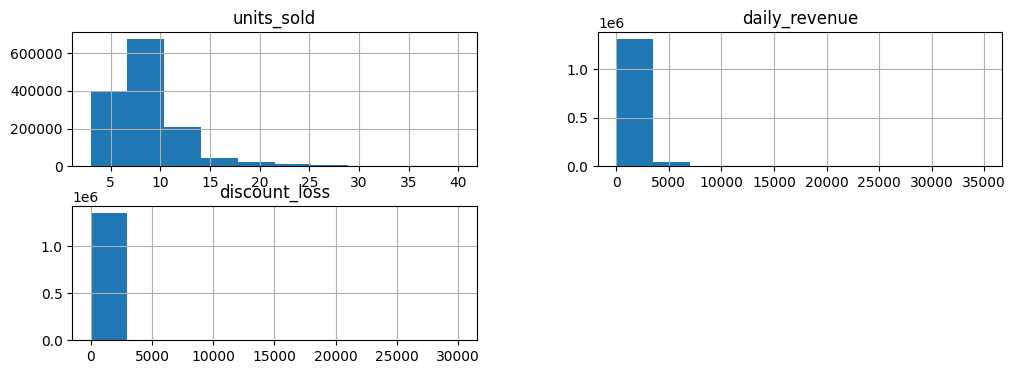

In [56]:
sales_df[
    [
        "units_sold",
        "daily_revenue",
        "discount_loss"
    ]
].hist(figsize=(12,4))

In [58]:
sales_df.to_csv(
    "zepto_sales_forecasting_dataset.csv",
    index=False
)

print("Dataset exported successfully!")

Dataset exported successfully!
